In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate
plt.style.use("ggplot")

In [2]:
import sys
import numpy
import pandas
import sklearn
import fairlearn
import matplotlib

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Fairlearn:", fairlearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.12.9 (tags/v3.12.9:fdb8142, Feb  4 2025, 15:27:58) [MSC v.1942 64 bit (AMD64)]
NumPy: 2.4.4
Pandas: 3.0.3
Scikit-learn: 1.8.0
Fairlearn: 0.14.0
Matplotlib: 3.10.9


---

***Step 0***

In [3]:
STUDENT_ID = 98
SEED = STUDENT_ID
random.seed(SEED)
np.random.seed(SEED)

In [4]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

compas_df = pd.read_csv(url)
print(compas_df.shape)
compas_df.head()

(7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [5]:
compas_df = compas_df[(compas_df["days_b_screening_arrest"] >= -30) & (compas_df["days_b_screening_arrest"] <= 30)]

compas_df = compas_df[compas_df["is_recid"] != -1]

compas_df = compas_df[compas_df["c_charge_degree"] != "O"]

compas_df = compas_df[compas_df["score_text"] != "N/A"]

print(compas_df.shape)

(6172, 53)


In [6]:
columns = [
    "age",
    "sex",
    "race",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree",
    "decile_score",
    "two_year_recid"]

compas_df = compas_df[columns]
compas_df.head()

,age,sex,race,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,decile_score,two_year_recid
0,69,Male,Other,0,0,0,0,F,1,0
1,34,Male,African-American,0,0,0,0,F,3,1
2,24,Male,African-American,4,0,0,1,F,4,1
5,44,Male,Other,0,0,0,0,M,1,0
6,41,Male,Caucasian,14,0,0,0,F,6,1


In [7]:
print(compas_df.isnull().sum())

age                0
sex                0
race               0
priors_count       0
juv_fel_count      0
juv_misd_count     0
juv_other_count    0
c_charge_degree    0
decile_score       0
two_year_recid     0
dtype: int64


In [8]:
target = "two_year_recid"
X = compas_df.drop(columns=[target])
y = compas_df[target]

In [9]:
protected_attribute = compas_df["race"]

In [10]:
X = pd.get_dummies(X, columns=["sex", "race", "c_charge_degree"], drop_first=True)
print(X.shape)
X.head()

(6172, 13)


,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,decile_score,sex_Male,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,c_charge_degree_M
0,69,0,0,0,0,1,True,False,False,False,False,True,False
1,34,0,0,0,0,3,True,False,False,False,False,False,False
2,24,4,0,0,1,4,True,False,False,False,False,False,False
5,44,0,0,0,0,1,True,False,False,False,False,True,True
6,41,14,0,0,0,6,True,False,True,False,False,False,False


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

In [12]:
print("Overall")
print(y.value_counts(normalize=True))

print("\nTrain")
print(y_train.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

Overall
two_year_recid
0    0.54488
1    0.45512
Name: proportion, dtype: float64

Train
two_year_recid
0    0.544865
1    0.455135
Name: proportion, dtype: float64

Test
two_year_recid
0    0.544939
1    0.455061
Name: proportion, dtype: float64


In [13]:
protected_test = compas_df.loc[X_test.index, "race"]
protected_test.head()

5530    African-American
2448    African-American
2693    African-American
3132    African-American
1111    African-American
Name: race, dtype: str

In [14]:
print("Train shape :", X_train.shape)
print("Test shape  :", X_test.shape)
print("Train labels:", y_train.shape)
print("Test labels :", y_test.shape)

Train shape : (4937, 13)
Test shape  : (1235, 13)
Train labels: (4937,)
Test labels : (1235,)


---

***Step 1***

**a)**

In [15]:
base_rate_percent = (
    compas_df
    .groupby("race")["two_year_recid"]
    .mean()
    .mul(100)
    .round(2)
)
print(base_rate_percent)

race
African-American    52.31
Asian               25.81
Caucasian           39.09
Hispanic            37.13
Native American     45.45
Other               36.15
Name: two_year_recid, dtype: float64


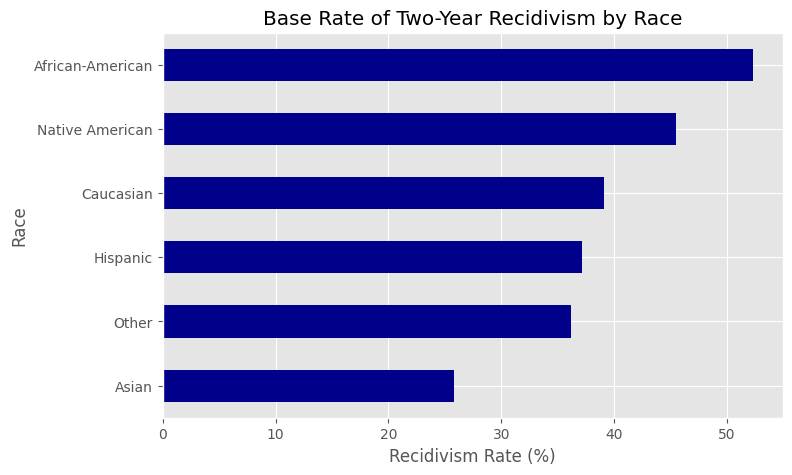

In [16]:
plt.figure(figsize=(8,5))
base_rate_percent.sort_values().plot(kind="barh", color="darkblue")
plt.xlabel("Recidivism Rate (%)")
plt.ylabel("Race")
plt.title("Base Rate of Two-Year Recidivism by Race")
plt.show()

**b)**

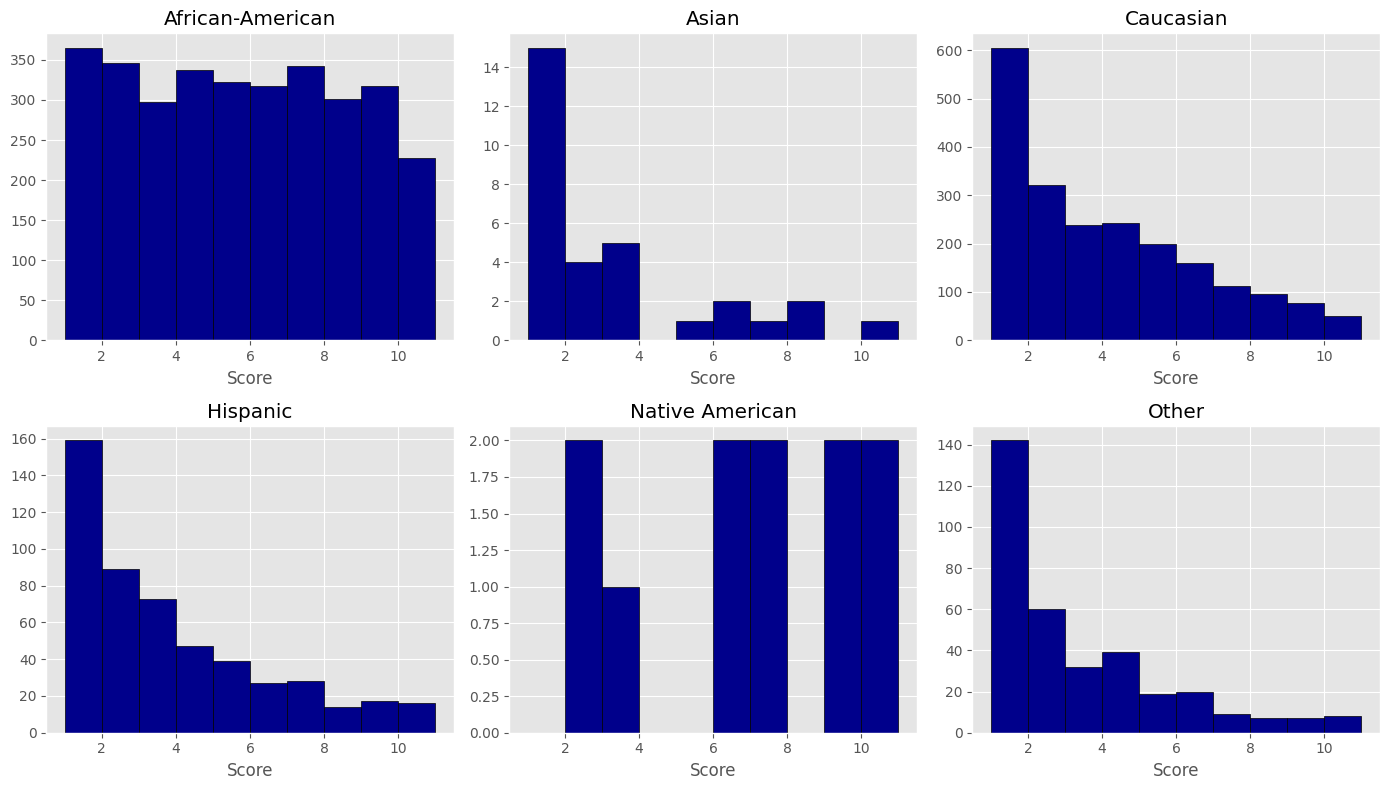

In [17]:
races = sorted(compas_df["race"].unique())
fig, axes = plt.subplots(2,3, figsize=(14,8))
axes = axes.flatten()
for ax, race in zip(axes, races):
    scores = compas_df.loc[compas_df["race"] == race, "decile_score"]
    ax.hist(scores, bins=np.arange(1,12), edgecolor='black', color="darkblue")
    ax.set_title(race)
    ax.set_xlabel("Score")
plt.tight_layout()
plt.show()

**c)**

In [18]:
tmp = compas_df.copy()
tmp["race_code"] = tmp["race"].astype("category").cat.codes

In [19]:
numeric_cols = [
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "decile_score",
    "race_code"
]

correlation = tmp[numeric_cols].corr()
print(correlation["race_code"].sort_values())

decile_score      -0.297781
priors_count      -0.198929
juv_misd_count    -0.077483
juv_other_count   -0.054797
juv_fel_count     -0.040137
age                0.132828
race_code          1.000000
Name: race_code, dtype: float64


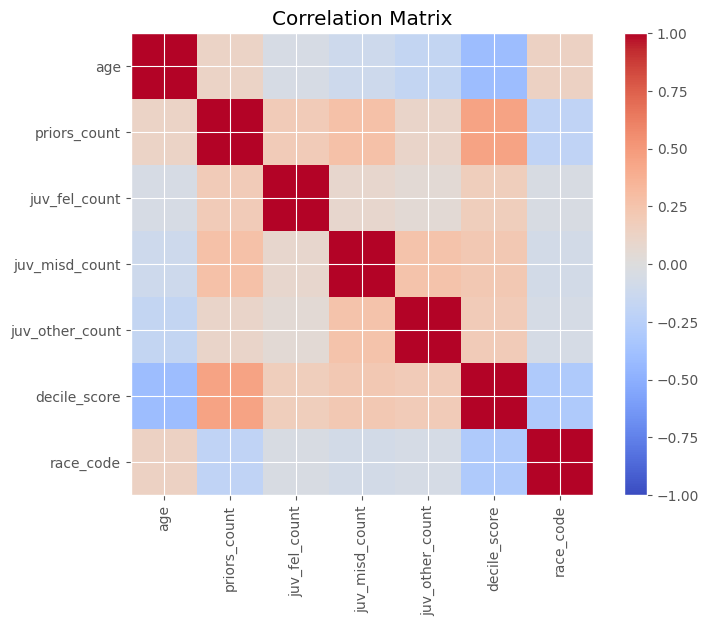

In [20]:
plt.figure(figsize=(8,6))
plt.imshow(correlation,
           cmap="coolwarm",
           vmin=-1,
           vmax=1)
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.show()

---

***Step 2***

**a)**

In [21]:
baseline_model = LogisticRegression(max_iter=1000, random_state=SEED)
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]
overall_accuracy = accuracy_score(y_test, y_pred)
overall_auc = roc_auc_score(y_test, y_prob)
print("=== Baseline Model ===")
print(f"Accuracy: {overall_accuracy:.4f}")
print(f"ROC-AUC : {overall_auc:.4f}\n")

=== Baseline Model ===
Accuracy: 0.6583
ROC-AUC : 0.7186



**b)**

In [22]:
def compute_fairness_metrics(y_true, y_pred, groups):
    df_eval = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'group': groups})
    results = {}
    for group in df_eval['group'].unique():
        sub = df_eval[df_eval['group'] == group]
        yt = sub['y_true'].values
        yp = sub['y_pred'].values
        tp = np.sum((yt == 1) & (yp == 1))
        tn = np.sum((yt == 0) & (yp == 0))
        fp = np.sum((yt == 0) & (yp == 1))
        fn = np.sum((yt == 1) & (yp == 0))
        
        sel_rate = np.mean(yp)                             
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0       
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0      
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0      
        
        results[group] = {
            'Count': int(len(sub)),
            'Selection Rate': sel_rate,
            'TPR': tpr,
            'FPR': fpr,
            'PPV': ppv
        }
    
    metrics_df = pd.DataFrame(results).T
    dp_diff = metrics_df['Selection Rate'].max() - metrics_df['Selection Rate'].min()
    eq_opp_diff = metrics_df['TPR'].max() - metrics_df['TPR'].min()
    fpr_diff = metrics_df['FPR'].max() - metrics_df['FPR'].min()
    gaps = {
        'Demographic Parity Difference': dp_diff,
        'Equal Opportunity Difference (TPR Gap)': eq_opp_diff,
        'FPR Difference': fpr_diff
    }
    
    return metrics_df, gaps

group_metrics_df, metrics_gaps = compute_fairness_metrics(y_true=y_test,  y_pred=y_pred,  groups=protected_test)

**c)**

In [23]:
print("Fairness Metrics Table by Racial Group:")
display(group_metrics_df.round(4))

Fairness Metrics Table by Racial Group:


,Count,Selection Rate,TPR,FPR,PPV
African-American,672.0,0.5238,0.6736,0.3731,0.6449
Caucasian,380.0,0.3079,0.4771,0.1938,0.6239
Hispanic,107.0,0.3178,0.4286,0.2462,0.5294
Other,70.0,0.1571,0.3000,0.0500,0.8182
Asian,5.0,0.0000,0.0000,0.0000,0.0000
Native American,1.0,0.0000,0.0000,0.0000,0.0000


In [24]:
print("Inter-Group Disparities:")
for metric_name, val in metrics_gaps.items():
    print(f"{metric_name}: {val:.4f}")

Inter-Group Disparities:
Demographic Parity Difference: 0.5238
Equal Opportunity Difference (TPR Gap): 0.6736
FPR Difference: 0.3731


---

***Step 3***

In [25]:
race_cols_to_drop = [col for col in X_train.columns if col.startswith("race_")]
X_train_unaware = X_train.drop(columns=race_cols_to_drop)
X_test_unaware = X_test.drop(columns=race_cols_to_drop)
print(f"Features before dropping race: {X_train.shape[1]}")
print(f"Features after dropping race : {X_train_unaware.shape[1]}")

Features before dropping race: 13
Features after dropping race : 8


In [26]:
unaware_model = LogisticRegression(max_iter=1000, random_state=SEED)
unaware_model.fit(X_train_unaware, y_train)

y_pred_unaware = unaware_model.predict(X_test_unaware)
y_prob_unaware = unaware_model.predict_proba(X_test_unaware)[:, 1]

unaware_acc = accuracy_score(y_test, y_pred_unaware)
unaware_auc = roc_auc_score(y_test, y_prob_unaware)

print(f"Unaware Model Overall Performance:")
print(f"Accuracy = {unaware_acc:.4f}")
print(f"ROC-AUC = {unaware_auc:.4f}\n")

Unaware Model Overall Performance:
Accuracy = 0.6526
ROC-AUC = 0.7187



In [27]:
unaware_metrics_df, unaware_gaps = compute_fairness_metrics(
    y_true=y_test, 
    y_pred=y_pred_unaware, 
    groups=protected_test
)

print("Fairness Metrics Table by Racial Group (Unaware Model):")
display(unaware_metrics_df.round(4))

Fairness Metrics Table by Racial Group (Unaware Model):


,Count,Selection Rate,TPR,FPR,PPV
African-American,672.0,0.5193,0.6677,0.3701,0.6447
Caucasian,380.0,0.2947,0.4444,0.1938,0.6071
Hispanic,107.0,0.3364,0.4286,0.2769,0.5000
Other,70.0,0.2000,0.3667,0.0750,0.7857
Asian,5.0,0.0000,0.0000,0.0000,0.0000
Native American,1.0,0.0000,0.0000,0.0000,0.0000


In [28]:
print("Inter-Group Disparities (Unaware Model):")
for metric_name, val in unaware_gaps.items():
    print(f"{metric_name}: {val:.4f}")

Inter-Group Disparities (Unaware Model):
Demographic Parity Difference: 0.5193
Equal Opportunity Difference (TPR Gap): 0.6677
FPR Difference: 0.3701


---

***Step 4***

In [29]:
mitigated_inproc = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    constraints=EqualizedOdds(),
    eps=0.01
)
mitigated_inproc.fit(X_train, y_train, sensitive_features=compas_df.loc[X_train.index, "race"])
y_pred_inproc = mitigated_inproc.predict(X_train) 
y_pred_inproc_test = mitigated_inproc.predict(X_test)
y_prob_inproc_test = mitigated_inproc.predict_proba(X_test)[:, 1] if hasattr(mitigated_inproc, "predict_proba") else y_pred_inproc_test

In [30]:
mitigated_postproc = ThresholdOptimizer(
    estimator=baseline_model,
    constraints="equalized_odds",
    objective="accuracy_score"
)
mitigated_postproc.fit(X_train, y_train, sensitive_features=compas_df.loc[X_train.index, "race"])
y_pred_postproc_test = mitigated_postproc.predict(X_test, sensitive_features=protected_test)

inproc_metrics_df, inproc_gaps = compute_fairness_metrics(y_true=y_test, y_pred=y_pred_inproc_test, groups=protected_test)
postproc_metrics_df, postproc_gaps = compute_fairness_metrics(y_true=y_test, y_pred=y_pred_postproc_test, groups=protected_test)

In [31]:
acc_baseline = accuracy_score(y_test, y_pred)
acc_unaware = accuracy_score(y_test, y_pred_unaware)
acc_inproc = accuracy_score(y_test, y_pred_inproc_test)
acc_postproc = accuracy_score(y_test, y_pred_postproc_test)

comparison_summary = pd.DataFrame({
    "Baseline": [acc_baseline, metrics_gaps['Demographic Parity Difference'], metrics_gaps['Equal Opportunity Difference (TPR Gap)'], metrics_gaps['FPR Difference']],
    "Unaware": [unaware_acc, unaware_gaps['Demographic Parity Difference'], unaware_gaps['Equal Opportunity Difference (TPR Gap)'], unaware_gaps['FPR Difference']],
    "In-Processing (Eq. Odds)": [acc_inproc, inproc_gaps['Demographic Parity Difference'], inproc_gaps['Equal Opportunity Difference (TPR Gap)'], inproc_gaps['FPR Difference']],
    "Post-Processing (Threshold)": [acc_postproc, postproc_gaps['Demographic Parity Difference'], postproc_gaps['Equal Opportunity Difference (TPR Gap)'], postproc_gaps['FPR Difference']]
}, index=["Accuracy", "Demographic Parity Gap", "Equal Opportunity Gap (TPR)", "FPR Gap"])

display(comparison_summary.round(4))

,Baseline,Unaware,In-Processing (Eq. Odds),Post-Processing (Threshold)
Accuracy,0.6583,0.6526,0.6526,0.6356
Demographic Parity Gap,0.5238,0.5193,0.4393,0.4486
Equal Opportunity Gap (TPR),0.6736,0.6677,0.5667,0.6013
FPR Gap,0.3731,0.3701,0.4154,0.3846


---

***Step 5***

**a)**

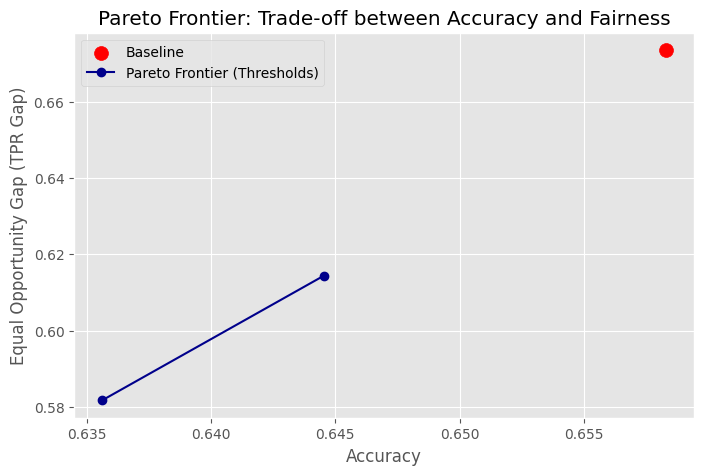

In [32]:
accuracies = []
fairness_gaps = []

for constraint_type in ["demographic_parity", "equalized_odds"]:
    post_opt = ThresholdOptimizer(
        estimator=baseline_model,
        constraints=constraint_type,
        objective="accuracy_score"
    )
    post_opt.fit(X_train, y_train, sensitive_features=compas_df.loc[X_train.index, "race"])
    y_p = post_opt.predict(X_test, sensitive_features=protected_test)
    
    acc = accuracy_score(y_test, y_p)
    _, gaps = compute_fairness_metrics(y_true=y_test, y_pred=y_p, groups=protected_test)
    
    accuracies.append(acc)
    fairness_gaps.append(gaps['Equal Opportunity Difference (TPR Gap)'])

plt.figure(figsize=(8, 5))
plt.scatter([overall_accuracy], [metrics_gaps['Equal Opportunity Difference (TPR Gap)']], color='red', s=100, label='Baseline', zorder=5)
plt.plot(accuracies, fairness_gaps, marker='o', linestyle='-', color='darkblue', label='Pareto Frontier (Thresholds)')
plt.xlabel("Accuracy")
plt.ylabel("Equal Opportunity Gap (TPR Gap)")
plt.title("Pareto Frontier: Trade-off between Accuracy and Fairness")
plt.legend()
plt.grid(True)
plt.show()

**b)**

In [33]:
print("Quantitative Evaluation of Metrics for Impossibility Assessment:")
for group in group_metrics_df.index:
    print(f"Group: {group}")
    print(f"  - Selection Rate (Demographic): {group_metrics_df.loc[group, 'Selection Rate']:.4f}")
    print(f"  - TPR (Equal Opportunity): {group_metrics_df.loc[group, 'TPR']:.4f}")
    print(f"  - PPV: {group_metrics_df.loc[group, 'PPV']:.4f}")
    print(f"  - FPR: {group_metrics_df.loc[group, 'FPR']:.4f}")

Quantitative Evaluation of Metrics for Impossibility Assessment:
Group: African-American
  - Selection Rate (Demographic): 0.5238
  - TPR (Equal Opportunity): 0.6736
  - PPV: 0.6449
  - FPR: 0.3731
Group: Caucasian
  - Selection Rate (Demographic): 0.3079
  - TPR (Equal Opportunity): 0.4771
  - PPV: 0.6239
  - FPR: 0.1938
Group: Hispanic
  - Selection Rate (Demographic): 0.3178
  - TPR (Equal Opportunity): 0.4286
  - PPV: 0.5294
  - FPR: 0.2462
Group: Other
  - Selection Rate (Demographic): 0.1571
  - TPR (Equal Opportunity): 0.3000
  - PPV: 0.8182
  - FPR: 0.0500
Group: Asian
  - Selection Rate (Demographic): 0.0000
  - TPR (Equal Opportunity): 0.0000
  - PPV: 0.0000
  - FPR: 0.0000
Group: Native American
  - Selection Rate (Demographic): 0.0000
  - TPR (Equal Opportunity): 0.0000
  - PPV: 0.0000
  - FPR: 0.0000


---

***Step 6***

In [34]:
intersect_test = compas_df.loc[X_test.index, "race"] + "_" + compas_df.loc[X_test.index, "sex"]

intersect_metrics_df, intersect_gaps = compute_fairness_metrics(
    y_true=y_test, 
    y_pred=y_pred, 
    groups=intersect_test
)

print("Fairness Metrics Table for Intersectional Subgroups (Race × Sex):")
display(intersect_metrics_df.round(4))

Fairness Metrics Table for Intersectional Subgroups (Race × Sex):


,Count,Selection Rate,TPR,FPR,PPV
African-American_Male,554.0,0.5848,0.7285,0.4259,0.6543
Caucasian_Male,295.0,0.3356,0.4960,0.2176,0.6263
African-American_Female,118.0,0.2373,0.3261,0.1806,0.5357
Hispanic_Male,87.0,0.3563,0.4848,0.2778,0.5161
Caucasian_Female,85.0,0.2118,0.3929,0.1228,0.6111
Other_Male,61.0,0.1803,0.3214,0.0606,0.8182
Other_Female,9.0,0.0000,0.0000,0.0000,0.0000
Hispanic_Female,20.0,0.1500,0.2222,0.0909,0.6667
Asian_Male,5.0,0.0000,0.0000,0.0000,0.0000
Native American_Male,1.0,0.0000,0.0000,0.0000,0.0000


In [35]:
print("Intersectional Gaps:")
for metric_name, val in intersect_gaps.items():
    print(f"{metric_name}: {val:.4f}")

Intersectional Gaps:
Demographic Parity Difference: 0.5848
Equal Opportunity Difference (TPR Gap): 0.7285
FPR Difference: 0.4259
